Acurácia: 0.8260869565217391
Matriz de Confusão:
 [[ 96  16]
 [ 32 132]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80       112
           1       0.89      0.80      0.85       164

    accuracy                           0.83       276
   macro avg       0.82      0.83      0.82       276
weighted avg       0.83      0.83      0.83       276



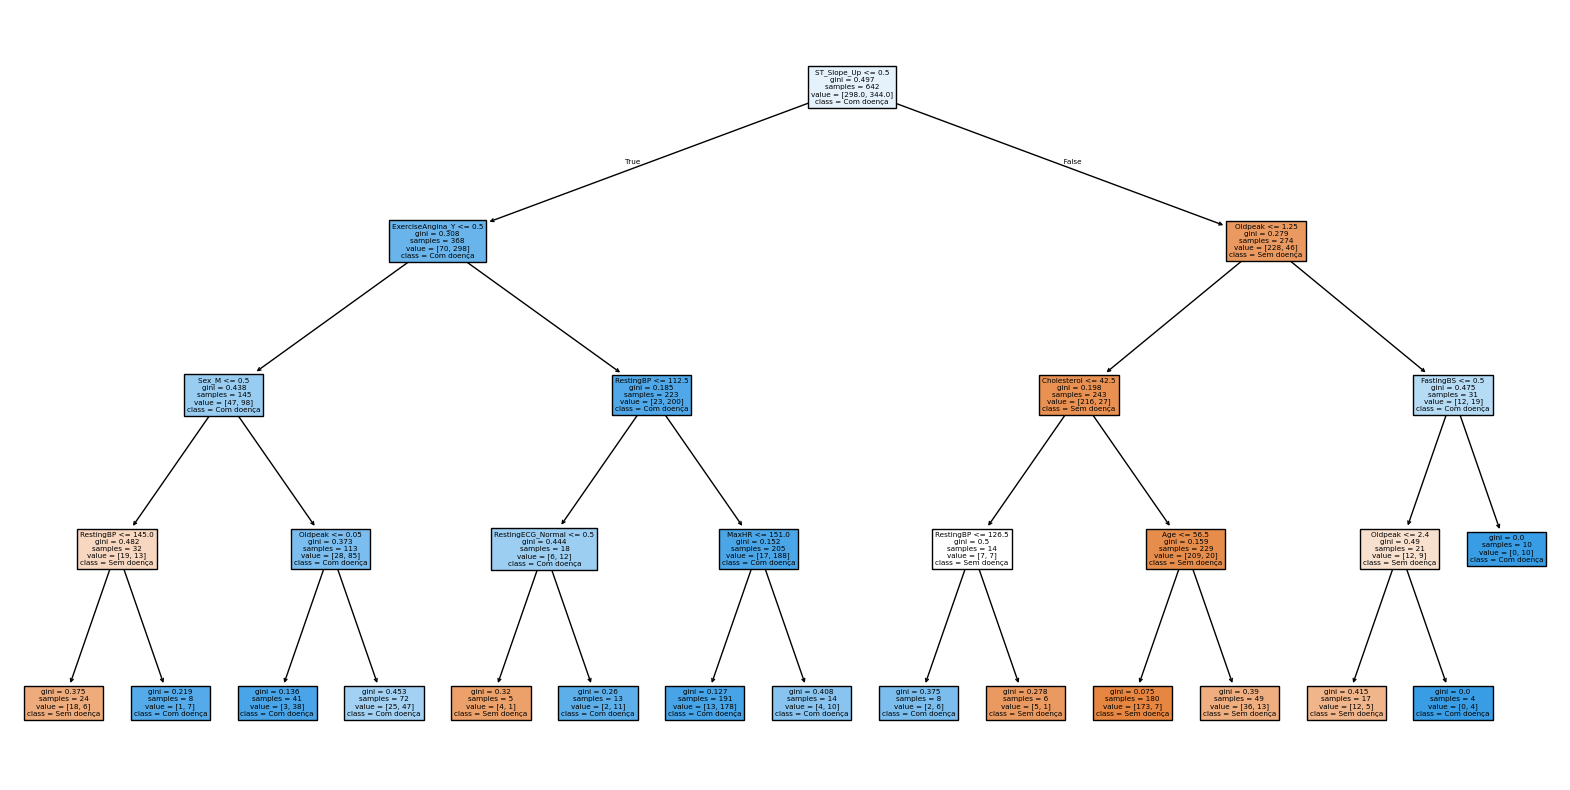

In [ ]:
# 1. Importar bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 2. Carregar dataset
df = pd.read_excel("heart_dataset.xlsx")

# 3. Separar features (X) e target (y)
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# 4. Transformar variáveis categóricas em numéricas
X = pd.get_dummies(X, drop_first=True)

# 5. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 6. Criar e treinar o modelo
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# 7. Fazer previsões
y_pred = model.predict(X_test)

# 8. Avaliar desempenho
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))
print("Relatório de Classificação:\n", classification_report(y_test, y_pred))

# 9. Visualizar a árvore
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=["Sem doença","Com doença"], filled=True)
plt.show()

Raiz (primeiro nó):

A árvore começa dividindo pela variável ST_Slope_Up.

Isso significa que o modelo considera a inclinação do segmento ST como o fator mais importante para separar pacientes com e sem doença.

O nó mostra:

gini = 0.497 → medida de impureza (quanto mais próximo de 0, mais puro).

samples = 842 → número de pacientes avaliados nesse ponto.

value = [298, 544] → distribuição entre classes (298 sem doença, 544 com doença).

class = Com doença → classe majoritária nesse nó.

Ramos (branches):

Cada condição (ex.: ExerciseAngina_Y <= 0.5) representa uma regra de decisão.

Se a condição é verdadeira, segue pelo ramo da esquerda; se é falsa, pelo da direita.

Isso vai refinando a classificação até chegar às folhas.

Folhas (leaves):

São os nós finais, onde não há mais divisão.

Cada folha mostra a classe prevista (sem doença ou com doença), junto com a pureza (gini) e a quantidade de amostras que chegaram até ali.

Exemplo: uma folha pode ter gini = 0.073, samples = 230, value = [221, 9], class = Sem doença.

Isso significa que, dos 230 pacientes que chegaram a esse ponto, 221 não têm doença e apenas 9 têm.

O modelo então classifica como sem doença.


Cores
Azul → nós onde a classe majoritária é com doença.

Laranja → nós onde a classe majoritária é sem doença.

Quanto mais forte a cor, mais puro é o nó (menos mistura entre classes).

In [ ]:
print("Profundidade da árvore:", model.get_depth())
print("Número de nós:", model.get_n_leaves())


Profundidade da árvore: 4
Número de nós: 15


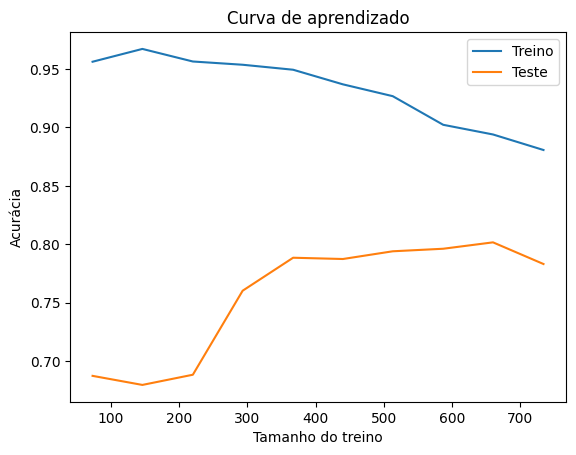

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Treino")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Teste")
plt.xlabel("Tamanho do treino")
plt.ylabel("Acurácia")
plt.legend()
plt.title("Curva de aprendizado")
plt.show()


In [1]:
!git clone https://github.com/nikolasluis/Aprendizado-de-M-quina-Supervisionado---Equipe-8.git
%cd Aprendizado-de-M-quina-Supervisionado---Equipe-8
!git checkout Decision_tree
!git add decision_tree_heart_disease.ipynb
!git commit -m "Adiciona notebook de árvore de decisão"
!git push origin Decision_tree


Cloning into 'Aprendizado-de-M-quina-Supervisionado---Equipe-8'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 15 (delta 5), reused 9 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 835.53 KiB | 3.07 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/Aprendizado-de-M-quina-Supervisionado---Equipe-8
Branch 'Decision_tree' set up to track remote branch 'Decision_tree' from 'origin'.
Switched to a new branch 'Decision_tree'
fatal: pathspec 'decision_tree_heart_disease.ipynb' did not match any files
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@da31b1c99c5e.(none)')
fatal: could not read Username for